# 02 — Gate Probabilities: the survival curve → the return on our shares

**How the project-success probabilities were derived from public data — the credit-risk → infrastructure bridge — and how they drive the value of the company we buy shares in.**

A develop-and-flip project must clear **three separate gates** to reach a sale; at each it either advances or stalls ('defaults'). True flip success is the **product** of the gate probabilities — structurally a multi-period **probability-of-default (PD) / survival** curve.

> **The key correction.** The founder's headline **40 / 65 / 80%** are the **development-approval gate ONLY** — not whole-funnel success. The gates *beyond* approval (grid connection, sale) are not free, so true flip success = approval × connection × sale, far below 65%.

| Gate | Public source | Metric |
|---|---|---|
| Development approval | NSW/VIC/SA planning portals | approval rate + timeline |
| Grid connection | AEMO Connections Scorecard / KCI (sub-5 MW exemption may help) | connection success + duration |
| Reach sale (flip exit) | RTB buyer-pool depth + AEMO proposed→committed attrition | conversion rate |

*Educational; not investment advice. Founder figures are claims to verify. See `../financial_models/SOURCES_LOG.md` for LIVE vs BENCHMARK status.*

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from src import valuation_engine as ve
inp = ve.load_inputs(); s = ve.summary(inp)
plt.rcParams['figure.figsize'] = (7, 4)
NAVY, ACCENT, RED = '#1F3864', '#2E75B6', '#C00000'

## 1. The per-gate statistics (`data/processed/gate_stats.csv`)

In [2]:
gates = pd.read_csv('../data/processed/gate_stats.csv')
gates

,gate,probability,duration_years,source,as_at,status
0,development_approval,0.8,1.25,NSW Planning Portal — approved vs refused/with...,2026-06-24,BENCHMARK
1,grid_connection,0.7,1.50,AEMO Connections Scorecard / KCI — connection ...,2026-06-24,BENCHMARK
2,reach_sale,0.8,0.50,AEMO proposed->committed attrition + active bu...,2026-06-24,BENCHMARK


## 2. Cumulative survival = product of gate probabilities

Python computes the *raw per-gate rates*; the Excel `Calc_Survival` tab builds the cumulative curve from them. This is the model's **independent** estimate.

In [3]:
sc = ve.survival_curve(inp)   # uses the independent public-benchmark approval rate
print(f"Development approval {sc['development_approval']:.0%}  ->  Connection {sc['grid_connection']:.0%}  ->  Sale {sc['reach_sale']:.0%}")
print(f"Independent flip success = {sc['development_approval']:.2f} x {sc['grid_connection']:.2f} x "
      f"{sc['reach_sale']:.2f} = {sc['flip_cumulative']:.1%}")

Development approval 80%  ->  Connection 70%  ->  Sale 80%
Independent flip success = 0.80 x 0.70 x 0.80 = 44.8%


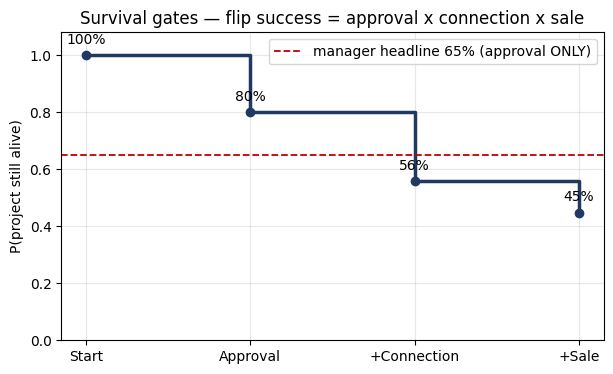

In [4]:
stages = ['Start', 'Approval', '+Connection', '+Sale']
surv = [1.0, sc['after_approval'], sc['after_connection'], sc['flip_cumulative']]
fig, ax = plt.subplots()
ax.step(range(4), surv, where='post', color=NAVY, lw=2.5, marker='o')
[ax.annotate(f'{v:.0%}', (i, v), textcoords='offset points', xytext=(0, 8), ha='center') for i, v in enumerate(surv)]
ax.axhline(s['da_base_manager'], color=RED, ls='--', lw=1.3, label=f"manager headline {s['da_base_manager']:.0%} (approval ONLY)")
ax.set_xticks(range(4)); ax.set_xticklabels(stages); ax.set_ylim(0, 1.08)
ax.set_ylabel('P(project still alive)'); ax.set_title('Survival gates — flip success = approval x connection x sale')
ax.legend(); ax.grid(alpha=.3)
plt.show()

## 3. The headline DD finding — the 65% is the development-approval gate ONLY

The manager's deck quotes **40 / 65 / 80%**. Those are the **development-approval gate**, not the probability of a completed flip. A project that wins approval must still **connect to the grid (~70%)** and **find a buyer (~80%)**. So true flip success at the manager's Base = **65% × 70% × 80% ≈ 36%** — not 65%. The table below shows the overstatement at each scenario.

In [5]:
rows = []
for cid, case in inp.scenarios.items():
    da = case['da_rate']
    flip = inp.flip_success(da)   # DA x grid connection x sale
    rows.append({'scenario': case['name'], 'DA gate (manager claim)': da,
                 'flip success (DA x conn x sale)': round(flip, 3)})
df = pd.DataFrame(rows)
df['headline overstatement'] = df['DA gate (manager claim)'] - df['flip success (DA x conn x sale)']
df

,scenario,DA gate (manager claim),flip success (DA x conn x sale),headline overstatement
0,Conservative,0.40,0.224,0.176
1,Base,0.65,0.364,0.286
2,Ideal,0.80,0.448,0.352


## 4. From the survival curve to the return on OUR shares

**Flip success** (= development approval × grid connection × sale) drives the company's funnel: `projects_started = target ÷ flip success`, so a lower success forces a bigger (more expensive) development programme. The company's **net programme profit** (gross proceeds − development cost) × a platform exit multiple gives its **exit equity value**. We then run that through the **cap table** — our ownership (= investment ÷ post-money), less dilution, with a 1× liquidation preference — to get the **return on our shares (MOIC and IRR)**. No fund fees or carry: we own shares directly.

In [6]:
rbs = ve.returns_by_scenario(inp)        # return on OUR shares
ct = ve.cap_table(inp)
print(f"Our stake: ${ct['investment']:.0f}m into ${ct['pre_money']:.0f}m pre-money "
      f"-> {ct['ownership_initial']:.0%} at entry, {ct['ownership_diluted']:.0%} after dilution")
rows = []
for name in ['Conservative', 'Base', 'Ideal']:
    m = rbs[name]
    rows.append({'scenario': name, 'flip success': f"{m['flip_success']:.0%}",
                 'company exit equity $m': round(m['company_exit_equity'], 1),
                 'our proceeds $m': round(m['our_proceeds'], 2),
                 'MOIC': round(m['moic'], 2), 'IRR': f"{m['irr']:.0%}"})
pd.DataFrame(rows)

Our stake: $2m into $8m pre-money -> 20% at entry, 14% after dilution


,scenario,flip success,company exit equity $m,our proceeds $m,MOIC,IRR
0,Conservative,22%,0.0,0.00,0.00,-100%
1,Base,36%,19.3,2.78,1.39,7%
2,Ideal,45%,51.9,7.47,3.74,30%


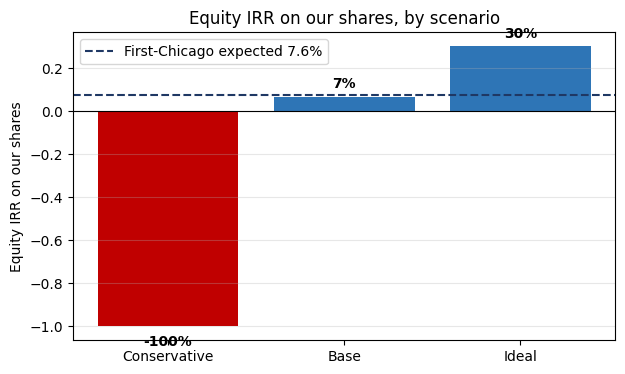

In [7]:
names = ['Conservative', 'Base', 'Ideal']
irrs = [rbs[n]['irr'] for n in names]
fig, ax = plt.subplots()
bars = ax.bar(names, irrs, color=[RED if v < 0 else ACCENT for v in irrs])
fc = ve.first_chicago(inp)
ax.axhline(0, color='black', lw=.8)
ax.axhline(fc['expected_irr'], color=NAVY, ls='--', lw=1.5,
           label=f"First-Chicago expected {fc['expected_irr']:.1%}")
[ax.annotate(f'{v:.0%}', (b.get_x()+b.get_width()/2, v), textcoords='offset points',
             xytext=(0, 6 if v >= 0 else -14), ha='center', fontweight='bold') for b, v in zip(bars, irrs)]
ax.set_ylabel('Equity IRR on our shares'); ax.set_title('Equity IRR on our shares, by scenario')
ax.legend(); ax.grid(axis='y', alpha=.3)
plt.show()

## 5. Probability-weighted (First-Chicago) expected return

In [8]:
fc = ve.first_chicago(inp)
print(f"First-Chicago expected return on our shares: IRR {fc['expected_irr']:.1%}  (MOIC {fc['expected_moic']:.2f}x)")
print(f"Scenario IRR range: {fc['min_irr']:.0%} .. {fc['max_irr']:.0%}  (Conservative is a total loss)")
print("Expected proceeds are weighted across scenarios, THEN converted to a MOIC/IRR — a "
      "-100% scenario can't be linearly averaged. Equity-deal terms (pre-money, dilution, "
      "exit multiple, exit year) are placeholders to confirm.")

First-Chicago expected return on our shares: IRR 7.6%  (MOIC 1.44x)
Scenario IRR range: -100% .. 30%  (Conservative is a total loss)
Expected proceeds are weighted across scenarios, THEN converted to a MOIC/IRR — a -100% scenario can't be linearly averaged. Equity-deal terms (pre-money, dilution, exit multiple, exit year) are placeholders to confirm.


**Takeaway.** The survival curve is the analytical centrepiece: a transparent, public-data PD/survival model that feeds the company's development funnel, its exit equity value, and — through the cap table — the **return on our shares**. The honest result: **the founder's 65% is the development-approval gate alone; true flip success ≈ 36% at Base; the Conservative case is a total loss; and the expected return on our shares is only modestly positive.** That is exactly the credit-style scepticism a brand-new startup warrants — and it argues for a heavier weight on the failure scenario and stronger downside terms (liquidation preference). See the Excel `Calc_Survival`, `Calc_Company` and `Returns` (cap table) tabs.